# APPM 4600 HW4 - Charlie Caravati

In [1]:
import numpy as np
import matplotlib.pyplot as plt

> ### 1. 

Let $f(x)$ denote a function with root $\alpha$ and multiplicity $m \gt 1$.

> (a) formal mathematical definition of what it means for $\alpha$ to be a root of multiplicity $m$ of $f(x)$

Let $\alpha$ be a real number and $f(x)$ be a function that is $m$ times continuously differentiable on an open interval containing $\alpha$ and $m$ is a positive integer. $\alpha$ is a root of multiplicity $m$ of $f(x) = 0$ if it satisfies two conditions. 

First, $f(x)$ can be factored as $f(x) = (x - \alpha)^m g(x)$ where $g(x)$ is continuous at $\alpha$ and $ g(\alpha) \neq 0$. 

Secondly, f(x) and the first m-1 derivatives evaluated at $\alpha$ must equal to 0 with the m derivate at $\alpha$ not equal to 0.

 $ f(\alpha) = 0, f'(\alpha) = 0, , f''(\alpha) = 0, ... , f^{m-1}(\alpha) = 0$ AND $f^m({\alpha}) \neq 0$

 > (b) show that newton's method applied to f(x) only converges linearly to the root $\alpha$

For Newton's, $g(x) = x - \frac{f(x)}{f'(x)}$

$g'(x) = 1 - \frac{f'(x)^2 - f(x)f''(x)}{f'(x)^2} = \frac{f(x)f''(x)}{f'(x)^2}$

For root $\alpha$ and multiplicity $m$ near $\alpha$, $f(x) = c(x-\alpha)^m, f'(x) = cm(x-\alpha)^{m-1},f''(x) = cm(m-1)(x-\alpha)^{m-2} $

$g'(\alpha) = \lim_{x \to \alpha}{\frac{(c(x-\alpha)^m)(cm(m-1)(x-\alpha)^{m-2})}{(cm(x-\alpha)^{m-1})^2}} = \lim_{x \to \alpha}{\frac{m(m-1)c^2(x-\alpha)^{2m-2}}{m^2c^2(x-\alpha)^{2m-2}}} = \frac{m-1}{m}$

Since $0 \lt g'(\alpha)= \frac{m-1}{m} \lt 1$, the function converges linearly with rate $\frac{m-1}{m}$

> (c) show fixed point iteration on $g(x) = x - m \frac{f(x)}{f'(x)}$ is second order convergent

$g'(x) = 1 - m(1 - \frac{f(x)f''(x)}{f'(x)^2}) = 1 - m + m\frac{f(x)f''(x)}{f'(x)^2}$

Plugging in the same $f(x) = c(x-\alpha)^m, f'(x) = cm(x-\alpha)^{m-1},f''(x) = cm(m-1)(x-\alpha)^{m-2}$ simplified above gives

$g'(x) = 1 - m + m(\frac{m-1}{m}) = 1 - m + (m - 1) = 0$

> (d) 

The modified Newton's method in part (c) allows us to return quadratic convergence to Newton's method even when multiplicity is higher than 1. 

> ### 2.

$\{x_k\}_{k=1}^{\infty}$ converges to a root $\alpha$ with order of convergence $p$ if there is a positive error constant $\lambda \gt 0$ such that $\lim_{k \to \infty}\frac{|x_{k+1}-\alpha|}{|x_k-\alpha|^{p}} = \lambda$.

For large values of k as $x_k$ approaches the root, $|x_{k+1}-\alpha| \approx \lambda |x_k-\alpha|^{p}$ then

$log(|x_{k+1}-\alpha|) \approx log(\lambda |x_k-\alpha|^{p})$ gives $log(|x_{k+1}-\alpha|) \approx p[log(|x_k-\alpha|)] + log(\lambda)$

To solve for $p$, subtracting $log(|x_{k+1}-\alpha|) \approx p[log(|x_k-\alpha|)] + log(\lambda)$$ from $log(|x_{k+2}-\alpha|) \approx p[log(|x_{k+1}-\alpha|)] + log(\lambda)$ gives

$log(|x_{k+2}-\alpha|) - log(|x_{k+1}-\alpha|) \approx p[log(|x_{k+1}-\alpha|)] + log(\lambda) - (p[log(|x_k-\alpha|)] + log(\lambda))$

$log(|x_{k+2}-\alpha|) - log(|x_{k+1}-\alpha|) \approx p[log(|x_{k+1}-\alpha|)] - p[log(|x_k-\alpha|)]$

$log(|x_{k+2}-\alpha|) - log(|x_{k+1}-\alpha|) \approx p[log(|x_{k+1}-\alpha|) - log(|x_k-\alpha|)]$

$ \ p \approx \frac{log(|x_{k+2}-\alpha|) - log(|x_{k+1}-\alpha|)}{log(|x_{k+1}-\alpha|) - log(|x_k-\alpha|)}$ as $k \to \infty$


> ### 3

In [2]:
def bisec_newt(f,fp, f2p, a,b, tol, nmax):

    # first verify there is a root we can find in the interval
    fa = f(a)
    fb = f(b)
    if (fa*fb>0):
        ier = 1
        astar = a
        return "Invalid interval"
    
    # verify end points are not a root
    if (fa == 0):
        astar = a
        ier =0
        return "a end point is a root"
    
    if (fb ==0):
        astar = b
        ier = 0
        return "b end point is a root"

    history = []
    count = 0
    while count < nmax:
        count += 1
        d = 0.5*(a+b)
        fd = f(d)
        fpd = fp(d)
        f2pd = f2p(d)

        history.append(d)

        if (fd ==0):
            return history

        check = (fd * f2pd) / (fpd**2) if fpd != 0 else float('infinity error')

        if check <= 1:
            break

        if (fa*fd<0):
            b = d
        else:
            a = d
            fa = fd

    p0 = d
    
    # Newton Method
    for i in range(nmax):
        p1 = p0-f(p0)/fp(p0)
        history.append(p1)
        if (abs(p1-p0) < tol):
            return history
        p0 = p1
    return history

In [3]:
def mod_newt(f, fp, p0, m, tol, nmax):
    history = [p0]
    for i in range(nmax):
        p1 = p0 - m * (f(p0)/fp(p0))
        history.append(p1)
        if (abs(p1-p0) < tol):
            pstar = p1
            return history
        p0 = p1
    pstar = p1
    return history

In [4]:
def newt(f, fp, p0, tol, nmax):
    history = [p0]
    for i in range(nmax):
        p1 = p0 - (f(p0)/fp(p0))
        history.append(p1)
        if (abs(p1-p0) < tol):
            pstar = p1
            return history
        p0 = p1
    pstar = p1
    return history

In [5]:
f = lambda x: np.exp(3*x) - 27*x**6 + 27*x**4*np.exp(x) - 9*x**2*np.exp(2*x)
fp = lambda x: 3*np.exp(3*x) - 162*x**5 + 27*(x**4 + 4*x**3)*np.exp(x) - 18*(x**2 + x)*np.exp(2*x)
f2p = lambda x: 9*np.exp(3*x) - 810*x**4 + 27*(x**4 + 8*x**3 + 12*x**2)*np.exp(x) - 18*(2*x**2 + 4*x + 1)*np.exp(2*x)
a = 3
b = 5
eps = .000001
iter_max = 100000

In [6]:
newt_hist = newt(f, fp, 3, eps, iter_max)

modnewt_hist = mod_newt(f, fp, 3, 3, eps, iter_max)

basin_hist = bisec_newt(f, fp, f2p, a, b, eps, iter_max)

newt_hist

[3,
 np.float64(4.105145154697739),
 np.float64(4.011727536183198),
 np.float64(3.9372977079439915),
 np.float64(3.8797708101464097),
 np.float64(3.836599680496835),
 np.float64(3.8050615667196817),
 np.float64(3.7825473213602754),
 np.float64(3.766772696087131),
 np.float64(3.755878452881054),
 np.float64(3.748434686765134),
 np.float64(3.7433874693034412),
 np.float64(3.739983641340661),
 np.float64(3.737696655373387),
 np.float64(3.736163970670873),
 np.float64(3.735138573438885),
 np.float64(3.734453359362835),
 np.float64(3.733995829404449),
 np.float64(3.7336904892604115),
 np.float64(3.7334867809296406),
 np.float64(3.733350914504082),
 np.float64(3.733260346046162),
 np.float64(3.7331999302207324),
 np.float64(3.7331593739667586),
 np.float64(3.7331326622380905),
 np.float64(3.7331155994062875),
 np.float64(3.7331036962031354),
 np.float64(3.733097155239259),
 np.float64(3.7330931174455095),
 np.float64(3.733079749176433),
 np.float64(3.7279777083601062),
 np.float64(3.72968619

In [7]:
def comp_ooc(history):
    diffs = [abs(history[n+1] - history[n]) for n in range(len(history) - 1)]
    ooc_list = []

    diffs = [d for d in diffs if d>0]
    
    for i in range(len(diffs) - 2):
        num = np.log(diffs[i+2]/diffs[i+1])
        den = np.log(diffs[i+1]/diffs[i])
        if den != 0:
            p = num/den
            ooc_list.append(p)
    return ooc_list

In [8]:
newt_ooc = comp_ooc(newt_hist)

newt_ooc

[np.float64(0.09196891484540295),
 np.float64(1.1337054087075351),
 np.float64(1.1144255508091636),
 np.float64(1.0936829132294505),
 np.float64(1.0734877737738087),
 np.float64(1.0554728486938236),
 np.float64(1.0405418046403858),
 np.float64(1.028877239032482),
 np.float64(1.0201709021304253),
 np.float64(1.0138894349724374),
 np.float64(1.009467178684923),
 np.float64(1.0064073470539001),
 np.float64(1.0043150687597535),
 np.float64(1.0028940239435495),
 np.float64(1.0019471229687094),
 np.float64(1.001304913138885),
 np.float64(1.0007941775094273),
 np.float64(1.0006913614248403),
 np.float64(1.0013561176238621),
 np.float64(0.9982461374534893),
 np.float64(0.9844540828177106),
 np.float64(1.0477371463564094),
 np.float64(1.0733091663697774),
 np.float64(0.8034243670651953),
 np.float64(1.6626807612105599),
 np.float64(0.8056916054169574),
 np.float64(-2.4817993106877503),
 np.float64(4.965406018572707),
 np.float64(-0.18404089485010508),
 np.float64(0.37422764263762565),
 np.float

In [9]:
mod_newt_ooc = comp_ooc(modnewt_hist)

mod_newt_ooc

[np.float64(0.11098738555643121),
 np.float64(1.7861862087741207),
 np.float64(1.855538187350459),
 np.float64(2.006422429072683),
 np.float64(2.085158854781379),
 np.float64(2.034734778924306),
 np.float64(-1.4994112254075689),
 np.float64(-0.016673863968736404),
 np.float64(20.388174533408833),
 np.float64(2.033492879259319)]

In [10]:
basin_ooc = comp_ooc(basin_hist)

basin_ooc

[np.float64(1.1115109967448673),
 np.float64(1.090726313706785),
 np.float64(1.0707570920295981),
 np.float64(1.0531448608402467),
 np.float64(1.0386827032141306),
 np.float64(1.027466548734943),
 np.float64(1.0191408289044983),
 np.float64(1.0131580625067127),
 np.float64(1.0089580125508026),
 np.float64(1.0060576604880178),
 np.float64(1.0040770540380122),
 np.float64(1.0027397695737887),
 np.float64(1.0018311431183025),
 np.float64(1.001251756475191),
 np.float64(1.0006795144344978),
 np.float64(1.0012979625060279),
 np.float64(0.9978850851820622),
 np.float64(1.0010916305027024),
 np.float64(0.9878647999392914),
 np.float64(0.998885701393299),
 np.float64(1.1218103655648757),
 np.float64(0.7554046553339416),
 np.float64(0.19098231531915866),
 np.float64(0.14784948293245492),
 np.float64(70.51379831807597),
 np.float64(-1.4644531518438844),
 np.float64(3.6767844974653867),
 np.float64(-0.30207019890170766),
 np.float64(0.3696584355072612),
 np.float64(0.9986558983594914),
 np.float6

> The modified Newton's method converges most quickly with quadratic convergence but requires knowing the multiplicity of a root. The basin of convergence into Newton's method might make the most sense in practice but requires a valid starting interval with sign change and the second derivative instead of just needing a good initial guess and first derivative. 

> ### 4.

$f(x) = x^6 - x - 1$

> (a)

In [11]:
def secant(f, p0, p1, tol, nmax):
    history = [p0, p1]
    for i in range(nmax):
        p2 = p1 - f(p1) * (p1 - p0) / (f(p1) - f(p0))
        history.append(p2)
        if (abs(p2-p1) < tol):
            return history
        p0 = p1
        p1 = p2

    return history

In [12]:
g = lambda x: x**6 - x - 1
gp = lambda x: 6*x**5 - 1
x0 = 2
x1 = 1
eps = 10e-15
iter_max = 100000

In [13]:
newt_roots = newt(g, gp, x0, eps, iter_max)

newt_roots

[2,
 1.6806282722513088,
 1.4307389882390624,
 1.2549709561094364,
 1.1615384327733131,
 1.1363532741705054,
 1.134730528343629,
 1.1347241385002211,
 1.1347241384015194,
 1.1347241384015194]

In [14]:
alpha = newt_roots[-1]

alpha**6 - alpha - 1

-8.881784197001252e-16

In [15]:
sec_roots = secant(g, x0, x1, eps, iter_max)

sec_roots

[2,
 1,
 1.0161290322580645,
 1.1905777686766374,
 1.1176558309415516,
 1.132531550216133,
 1.1348168080048529,
 1.134723645948705,
 1.1347241382912159,
 1.1347241384015196,
 1.1347241384015194]

In [16]:
alpha_sec = sec_roots[-1]
alpha_sec**6 - alpha_sec - 1

-8.881784197001252e-16

In [17]:
newt_error = [abs(alpha - r) for r in newt_roots]

newt_error

[0.8652758615984806,
 0.5459041338497894,
 0.296014849837543,
 0.12024681770791701,
 0.026814294371793723,
 0.0016291357689859343,
 6.389942109663593e-06,
 9.870171346904044e-11,
 0.0,
 0.0]

In [18]:
sec_error = [abs(alpha_sec - r) for r in sec_roots]

sec_error

[0.8652758615984806,
 0.13472413840151942,
 0.11859510614345492,
 0.05585363027511803,
 0.01706830745996779,
 0.0021925881853863682,
 9.266960333342844e-05,
 4.924528145267004e-07,
 1.1030354407637333e-10,
 2.220446049250313e-16,
 0.0]

> The error for both decreased as expected.

> (b)

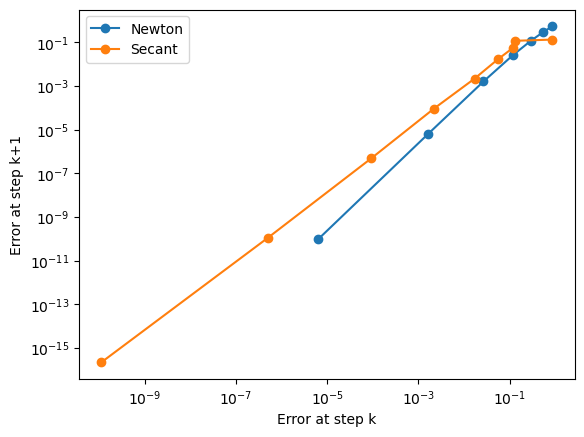

In [19]:
newt_err = [abs(alpha - r) for r in newt_roots if abs(alpha - r)>0]
sec_err = [abs(alpha_sec - r) for r in sec_roots if abs(alpha_sec - r)>0]

plt.loglog(newt_err[:-1], newt_err[1:], 'o-', label = 'Newton')
plt.loglog(sec_err[:-1], sec_err[1:], 'o-', label = 'Secant')
plt.xlabel('Error at step k')
plt.ylabel('Error at step k+1')
plt.legend()
plt.show()

> As the slopes are equal to the order of convergence we can calculate the slopes for the order of each algorithm.

In [22]:
newt_slope = np.polyfit(np.log10(newt_err[:-1]), np.log10(newt_err[1:]), 1)[0]
sec_slope = np.polyfit(np.log10(sec_err[:-1]), np.log10(sec_err[1:]), 1)[0]

print(f"Newton convergence order (slope): {newt_slope:.2f}")
print(f"Secant convergence order (slope): {sec_slope:.2f}")

Newton convergence order (slope): 1.92
Secant convergence order (slope): 1.57
